## Setup: Install Libraries and Mount Google Drive
Run the cells below to install necessary dependencies and mount your Google Drive to access the `Thermal Samples` dataset.

In [274]:
!pip install torch torchvision torchaudio scikit-learn matplotlib Pillow numpy

In [275]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# TODO: Update this path to the exact location of your project folder in Google Drive
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Colab Notebooks/Research/CoBas/Machine Learning'
THERMAL_SAMPLES_PATH = os.path.join(DRIVE_PROJECT_PATH, 'Thermal Samples')

print(f"Thermal Samples directory configured to: {THERMAL_SAMPLES_PATH}")

# Optional: Change the current working directory to the project folder
# os.chdir(DRIVE_PROJECT_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Thermal Samples directory configured to: /content/drive/MyDrive/Colab Notebooks/Research/CoBas/Machine Learning/Thermal Samples


# CoBas Thermal Image - Voice Reflection Multimodal Fusion Training

This notebook trains an image + STFT spectrogram fusion model using prepared pipeline outputs. It intentionally does not run video splitting, beacon cropping, audio extraction, STFT generation, or final spectrogram preprocessing. Those steps belong to the processing pipeline; this notebook starts from `Frames/` and `*_Spectogram/*.npy` files.

## Cell 1: Imports, reproducibility, and compute device


In [276]:
from __future__ import annotations

import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import models, transforms

# Use one seed so dataset splitting and model initialization are repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# CUDA will be used automatically when available.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Configuration

Set `SAMPLE_LABELS` to match your training samples. The keys are sample folder names under `Machine Learning/`, and the values are battery classes. Add more folders as the dataset grows.

## Cell 2: Training configuration and fixed class mapping


In [277]:
ML_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Research/CoBas/Machine Learning")
THERMAL_BASE = ML_ROOT / "Thermal Samples"

# Keep these labels fixed so model output index 0/1/2 always means 0%/50%/100%.
CLASS_NAMES = ["0%", "50%", "100%"]

# Using hard-coded absolute paths as requested
SAMPLE_LABELS = {
    str(THERMAL_BASE / "Sample_1/0_Percent_Thermal_with_voice_Image_and_Video"): "0%",
    str(THERMAL_BASE / "Sample_2/100_Percent_Thermal_with_voice_Image_and_Video"): "100%",
    str(THERMAL_BASE / "Sample_3/50_Percent_Thermal_with_voice_Image_and_Video"): "50%",
}

LABEL_TO_INDEX = {label: index for index, label in enumerate(CLASS_NAMES)}
INDEX_TO_LABEL = {index: label for label, index in LABEL_TO_INDEX.items()}

BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# Updated ratios: 70% Train, 20% Val, 10% Test
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.20
TEST_FRACTION = 0.10

MODEL_OUT = ML_ROOT / "Models" / "multimodal_fusion_model.pth"

print(f"Configured {len(SAMPLE_LABELS)} sample paths.")
display(LABEL_TO_INDEX)

Configured 3 sample paths.


{'0%': 0, '50%': 1, '100%': 2}

## Cell 3: Discover paired frame and spectrogram training samples


In [278]:
@dataclass(frozen=True)
class FusionSample:
    """One aligned multimodal training example from the pipeline output."""

    image_path: Path
    spectrogram_path: Path
    label: int
    sample_name: str
    segment_index: int


def segment_index_from_name(path: Path) -> int:
    """Read the numeric segment index from names like *_seg003.npy or *_frame003.jpg."""

    # Try to extract from _seg or _frame marker
    stem = path.stem
    for marker in ("_seg", "_frame"):
        marker_index = stem.rfind(marker)
        if marker_index != -1:
            return int(stem[marker_index + len(marker):marker_index + len(marker) + 3])

    raise ValueError(f"Could not find segment marker in {path.name}")


def find_pipeline_output(sample_dir: Path) -> Path:
    """Find the processed *_Image_and_Video folder inside one sample folder.

    If sample_dir itself is already a *_Image_and_Video folder, return it directly.
    """

    # Check if the sample_dir itself is a *_Image_and_Video folder
    if sample_dir.name.endswith("_Image_and_Video") and sample_dir.exists():
        return sample_dir

    # Otherwise, look for *_Image_and_Video folders inside it
    candidates = sorted(sample_dir.glob("*_Image_and_Video"))
    if not candidates:
        raise FileNotFoundError(f"No *_Image_and_Video folder found in {sample_dir}")
    return candidates[0]


def collect_samples(sample_labels: dict[str, str]) -> list[FusionSample]:
    """Pair each prepared STFT array with the frame that has the same index using absolute paths."""

    samples: list[FusionSample] = []

    for sample_path_str, label_name in sample_labels.items():
        sample_dir = Path(sample_path_str)
        output_dir = find_pipeline_output(sample_dir)
        frames_dir = output_dir / "Frames"
        spectrogram_dirs = sorted(output_dir.glob("*_Spectogram"))
        if not spectrogram_dirs:
            raise FileNotFoundError(f"No *_Spectogram folder found in {output_dir}")

        spectrogram_dir = spectrogram_dirs[0]
        if label_name not in LABEL_TO_INDEX:
            raise ValueError(f"Unknown label {label_name!r}. Use one of: {CLASS_NAMES}")

        label = LABEL_TO_INDEX[label_name]

        for spec_path in sorted(spectrogram_dir.glob("*.npy")):
            segment_index = segment_index_from_name(spec_path)
            matching_frames = list(frames_dir.glob(f"*_frame{segment_index:03d}.*"))

            if not matching_frames:
                continue

            frame_path = matching_frames[0]
            samples.append(FusionSample(frame_path, spec_path, label, sample_dir.name, segment_index))

    if not samples:
        raise RuntimeError("No paired frame/spectrogram samples were found with the provided absolute paths.")
    return samples

all_samples = collect_samples(SAMPLE_LABELS)
print(f"Total samples collected: {len(all_samples)}")
display(all_samples[:1])

Total samples collected: 415


[FusionSample(image_path=PosixPath('/content/drive/MyDrive/Colab Notebooks/Research/CoBas/Machine Learning/Thermal Samples/Sample_1/0_Percent_Thermal_with_voice_Image_and_Video/Frames/0_Percent_Thermal_with_voice_frame000.jpg'), spectrogram_path=PosixPath('/content/drive/MyDrive/Colab Notebooks/Research/CoBas/Machine Learning/Thermal Samples/Sample_1/0_Percent_Thermal_with_voice_Image_and_Video/0_Percent_Thermal_with_voice_Spectogram/0_Percent_Thermal_with_voice_beacon_seg000.npy'), label=0, sample_name='0_Percent_Thermal_with_voice_Image_and_Video', segment_index=0)]

## Cell 4: Crop and Convert Thermal Battery Image into a Predominant Color Spectrum

Processing random sample: 50_Percent_Thermal_with_voice_frame051.jpg (Label: 50%)


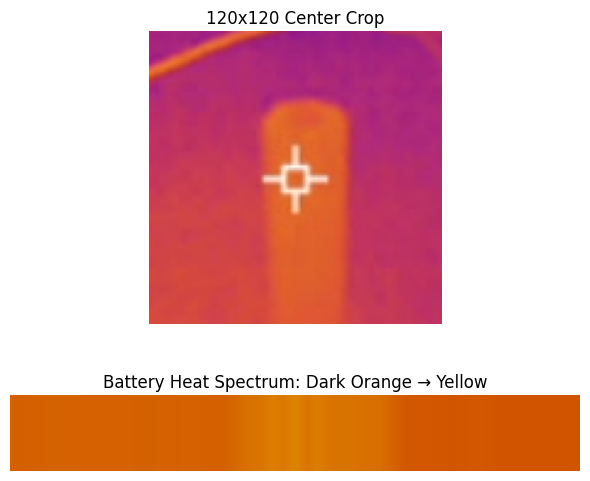

In [279]:
import numpy as np
from PIL import Image
from skimage import img_as_float
import matplotlib.pyplot as plt
import random


def process_battery_heat_spectrum(
    image_path,
    crop_size=120,
    spectrum_width=300,
    spectrum_height=40
):
    """
    Processes a thermal image and generates a heat-intensity spectrum.

    The spectrum represents battery heat from:
    - dark orange = lower heat intensity
    - yellow = higher heat intensity

    No denoising.
    No masking.
    No color exclusion.
    """

    # --------------------------------------------------
    # 1. Load image and center crop
    # --------------------------------------------------

    img = Image.open(image_path).convert("RGB")

    w, h = img.size

    left = int((w - crop_size) / 2)
    top = int((h - crop_size) / 2)
    right = left + crop_size
    bottom = top + crop_size

    cropped_img = img.crop((left, top, right, bottom))

    # --------------------------------------------------
    # 2. Convert crop to float array
    # --------------------------------------------------

    img_data = img_as_float(
        np.array(cropped_img)
    )

    # --------------------------------------------------
    # 3. Compute heat intensity from RGB image
    # --------------------------------------------------
    # Higher brightness means higher estimated heat intensity.

    heat_intensity = (
        0.299 * img_data[:, :, 0] +
        0.587 * img_data[:, :, 1] +
        0.114 * img_data[:, :, 2]
    )

    # Normalize heat intensity to 0-1
    min_intensity = np.min(heat_intensity)
    max_intensity = np.max(heat_intensity)

    if max_intensity > min_intensity:
        heat_intensity = (
            heat_intensity - min_intensity
        ) / (
            max_intensity - min_intensity
        )
    else:
        heat_intensity = np.zeros_like(heat_intensity)

    # --------------------------------------------------
    # 4. Build 1D heat profile across the crop
    # --------------------------------------------------
    # Average vertically, so each x-position gets one heat value.

    heat_profile = np.mean(
        heat_intensity,
        axis=0
    )

    # Resize heat profile to desired spectrum width
    original_x = np.linspace(
        0,
        1,
        heat_profile.shape[0]
    )

    target_x = np.linspace(
        0,
        1,
        spectrum_width
    )

    heat_profile_resized = np.interp(
        target_x,
        original_x,
        heat_profile
    )

    # --------------------------------------------------
    # 5. Convert heat intensity to dark-orange -> yellow colors
    # --------------------------------------------------

    dark_orange = np.array([0.80, 0.25, 0.00])  # dark orange
    yellow = np.array([1.00, 1.00, 0.00])       # yellow

    spectrum_colors = (
        dark_orange * (1.0 - heat_profile_resized[:, None]) +
        yellow * heat_profile_resized[:, None]
    )

    spectrum_colors = np.clip(
        spectrum_colors,
        0.0,
        1.0
    )

    # --------------------------------------------------
    # 6. Create horizontal spectrum strip
    # --------------------------------------------------

    spectrum_strip = np.tile(
        spectrum_colors[np.newaxis, :, :],
        (spectrum_height, 1, 1)
    )

    return cropped_img, spectrum_strip, heat_profile_resized


def show_battery_heat_spectrum(
    cropped_img,
    spectrum_strip
):
    """
    Displays only the center crop and the dark-orange-to-yellow heat spectrum.
    """

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(6, 6)
    )

    axes[0].imshow(cropped_img)
    axes[0].set_title("120x120 Center Crop")
    axes[0].axis("off")

    axes[1].imshow(spectrum_strip)
    axes[1].set_title("Battery Heat Spectrum: Dark Orange → Yellow")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


def generate_battery_heat_spectrum(
    image_path,
    crop_size=120,
    spectrum_width=300,
    spectrum_height=40
):
    """
    Wrapper function: process then plot.
    """

    cropped_img, spectrum_strip, heat_profile = process_battery_heat_spectrum(
        image_path=image_path,
        crop_size=crop_size,
        spectrum_width=spectrum_width,
        spectrum_height=spectrum_height
    )

    show_battery_heat_spectrum(
        cropped_img=cropped_img,
        spectrum_strip=spectrum_strip
    )

    return cropped_img, spectrum_strip, heat_profile


# --------------------------------------------------
# Select a random sample from your dataset
# --------------------------------------------------

random_sample = random.choice(all_samples)

print(
    f"Processing random sample: {random_sample.image_path.name} "
    f"(Label: {INDEX_TO_LABEL[random_sample.label]})"
)

# --------------------------------------------------
# Process and show battery heat spectrum
# --------------------------------------------------

cropped_img, spectrum_strip, heat_profile = generate_battery_heat_spectrum(
    image_path=str(random_sample.image_path),
    crop_size=120,
    spectrum_width=300,
    spectrum_height=40
)

## Cell 5: Dataset class and input tensor preparation


In [280]:
from skimage import img_as_float
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset
from torchvision import transforms


# --------------------------------------------------
# Transform for spectrum image (no additional cropping)
# --------------------------------------------------
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


# --------------------------------------------------
# Dataset class using dark-orange → yellow spectrum
# --------------------------------------------------
class CoBasFusionDataset(Dataset):
    """
    Loads RGB frames and converts each frame into a battery-heat spectrum image.

    The spectrum image goes from dark orange (low heat) to yellow (high heat)
    and is used as the visual input for the model.
    """

    def __init__(
        self,
        samples: list,
        image_transform=None,
        crop_size=120,
        spectrum_width=300,
        spectrum_height=40
    ):
        self.samples = samples
        self.image_transform = image_transform
        self.crop_size = crop_size
        self.spectrum_width = spectrum_width
        self.spectrum_height = spectrum_height

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]

        # Generate battery-heat spectrum (dark orange -> yellow)
        cropped_img, spectrum_strip, _ = process_battery_heat_spectrum(
            image_path=str(sample.image_path),
            crop_size=self.crop_size,
            spectrum_width=self.spectrum_width,
            spectrum_height=self.spectrum_height
        )

        # Convert spectrum to PIL
        spectrum_strip = np.clip(spectrum_strip, 0.0, 1.0)
        spectrum_uint8 = (spectrum_strip * 255).astype(np.uint8)
        image_pil = Image.fromarray(spectrum_uint8, mode="RGB")

        # Apply transform
        if self.image_transform is not None:
            image = self.image_transform(image_pil)
        else:
            image = transforms.ToTensor()(image_pil)

        # Load STFT spectrogram
        spectrogram = np.load(sample.spectrogram_path).astype(np.float32)
        spectrogram = np.nan_to_num(spectrogram, nan=0.0, posinf=0.0, neginf=0.0)
        spectrogram = torch.from_numpy(spectrogram).unsqueeze(0)

        # Label
        label = torch.tensor(sample.label, dtype=torch.long)

        return image, spectrogram, label


# --------------------------------------------------
# Initialize dataset and loaders
# --------------------------------------------------
dataset = CoBasFusionDataset(
    samples=all_samples,
    image_transform=image_transform,
    crop_size=120,
    spectrum_width=300,
    spectrum_height=40
)

train_loader, val_loader, test_loader = make_loaders(dataset)

print(
    f"Splits: Train({len(train_loader.dataset)}), "
    f"Val({len(val_loader.dataset)}), "
    f"Test({len(test_loader.dataset)})"
)

Splits: Train(290), Val(83), Test(42)


## Cell 6: Visualize one paired training sample


Showing random dataset index: 57


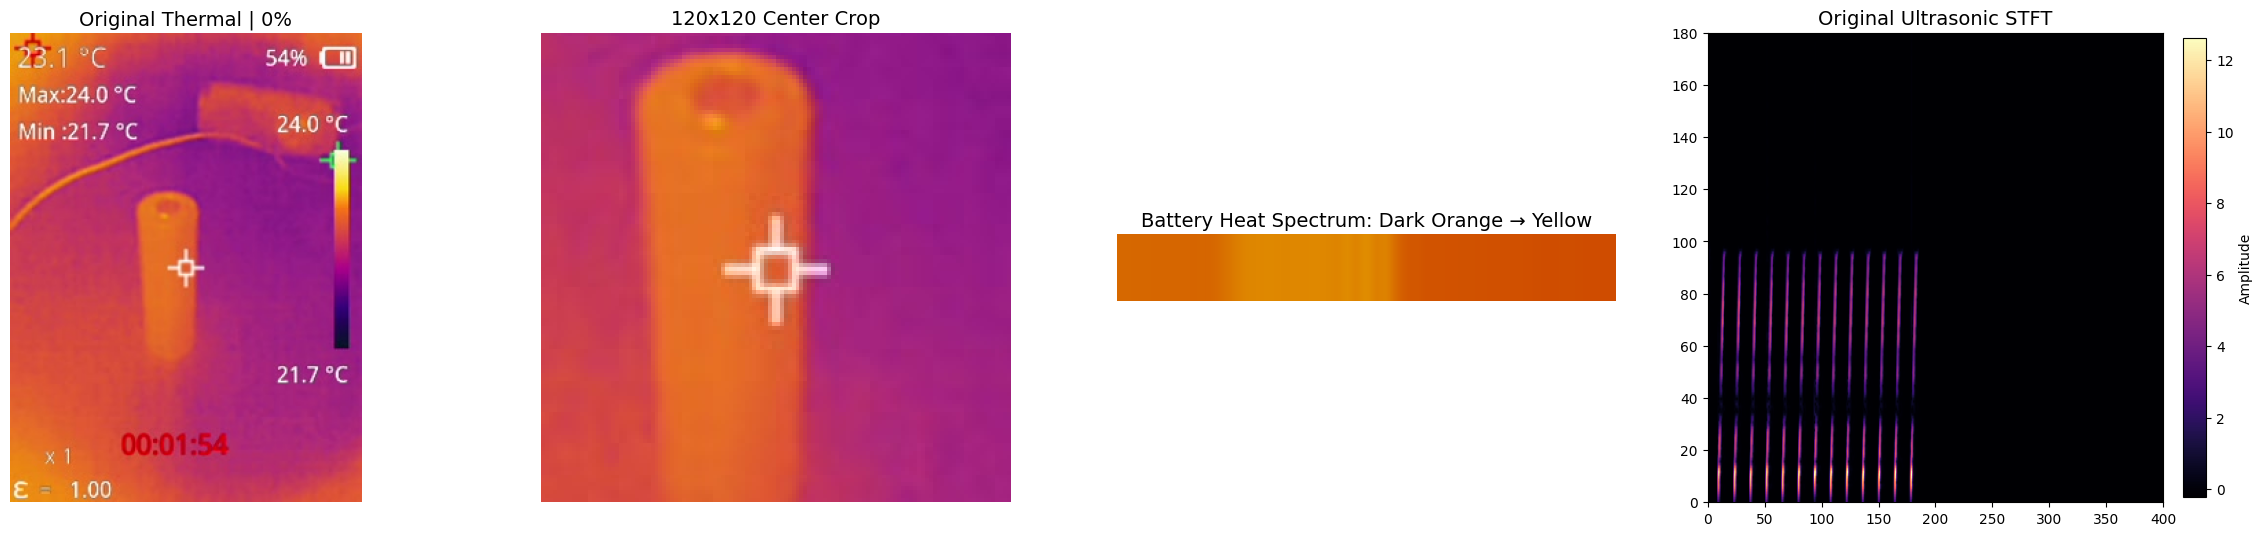

In [281]:
def show_sample_pair(dataset: CoBasFusionDataset, index: int = 0) -> None:
    """
    Show raw thermal frame, 120x120 cropped frame,
    dark-orange-to-yellow heat spectrum, and original STFT spectrogram.
    """

    sample = dataset.samples[index]

    # 1. Load original raw thermal image
    original_image = Image.open(sample.image_path).convert("RGB")

    # 2. Generate 120x120 crop and heat spectrum
    # Using *args to avoid unpacking errors if the signature changes
    results = process_battery_heat_spectrum(
        image_path=str(sample.image_path),
        crop_size=dataset.crop_size,
        spectrum_width=dataset.spectrum_width,
        spectrum_height=dataset.spectrum_height
    )

    cropped_img = results[0]
    spectrum_strip = results[1]
    # heat_profile is results[2]

    spectrum_strip = np.clip(spectrum_strip, 0.0, 1.0)

    # 3. Load original STFT spectrogram
    spectrogram = np.load(sample.spectrogram_path).astype(np.float32)
    spectrogram = np.nan_to_num(spectrogram, nan=0.0, posinf=0.0, neginf=0.0)

    # 4. Show raw image, crop, heat spectrum, and STFT
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # Original thermal image
    axes[0].imshow(original_image)
    axes[0].set_title(f"Original Thermal | {INDEX_TO_LABEL[sample.label]}", fontsize=14)
    axes[0].axis("off")

    # 120x120 center crop
    axes[1].imshow(cropped_img)
    axes[1].set_title("120x120 Center Crop", fontsize=14)
    axes[1].axis("off")

    # Dark-orange-to-yellow heat spectrum
    axes[2].imshow(spectrum_strip)
    axes[2].set_title("Battery Heat Spectrum: Dark Orange → Yellow", fontsize=14)
    axes[2].axis("off")

    # STFT spectrogram
    n_freq, n_time = spectrogram.shape
    extent = [0, int(np.ceil(n_time / 50) * 50), 0, int(np.ceil(n_freq / 20) * 20)]
    im = axes[3].imshow(spectrogram, aspect="auto", origin="lower", cmap="magma", extent=extent)
    axes[3].set_title("Original Ultrasonic STFT", fontsize=14)
    cbar = fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    cbar.set_label("Amplitude")

    plt.tight_layout(pad=3.0, w_pad=4.0)
    plt.show()

# Use a random index
random_index = random.randint(0, len(dataset.samples) - 1)
print(f"Showing random dataset index: {random_index}")
show_sample_pair(dataset, index=random_index)

## Cell 6: Train/validation/test split and DataLoaders


In [282]:
def make_loaders(
    dataset: Dataset,
    train_fraction: float = 0.70,
    val_fraction: float = 0.20,
    test_fraction: float = 0.10,
):
    """Create repeatable splits: 70% Train, 20% Val, 10% Test."""

    labels = np.array([dataset.samples[i].label for i in range(len(dataset))])
    indices = np.arange(len(dataset))

    # 1. Extract the Test set (10%)
    test_size = max(1, int(round(len(indices) * test_fraction)))
    remaining_indices, test_indices = train_test_split(
        indices,
        test_size=test_size,
        random_state=SEED,
        stratify=labels
    )

    # 2. Split the remaining pool (90%) into Train and Val
    # To get 20% of the total from the remaining 90%, we need a ratio of 0.2 / 0.9
    remaining_labels = labels[remaining_indices]
    val_ratio = val_fraction / (train_fraction + val_fraction)

    train_indices, val_indices = train_test_split(
        remaining_indices,
        test_size=val_ratio,
        random_state=SEED,
        stratify=remaining_labels
    )

    train_loader = DataLoader(Subset(dataset, train_indices), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_indices), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(Subset(dataset, test_indices), batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, test_loader

# Re-generate loaders with 70/20/10 split
train_loader, val_loader, test_loader = make_loaders(dataset)

print(f"Total dataset size: {len(dataset)}")
print(f"Train samples: {len(train_loader.dataset)} (70%)")
print(f"Validation samples: {len(val_loader.dataset)} (20%)")
print(f"Test samples: {len(test_loader.dataset)} (10%)")

Total dataset size: 415
Train samples: 290 (70%)
Validation samples: 83 (20%)
Test samples: 42 (10%)


## Model

This follows the old-code idea: one visual branch, one spectrogram branch, concatenate features, then classify.

## Cell 7: Multimodal fusion model definition


In [283]:
class SpectrogramCNN(nn.Module):
    """Small CNN that converts one STFT spectrogram into a feature vector."""

    def __init__(self, out_features: int = 256):
        super().__init__()
        # Convolutions learn local frequency/time patterns in the ultrasonic STFT.
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.projection = nn.Linear(128, out_features)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x).flatten(1)
        return self.projection(x)


class MultiModalFusionNet(nn.Module):
    """ResNet image branch + spectrogram CNN branch + fused classifier."""

    def __init__(self, num_classes: int, image_features: int = 256, audio_features: int = 256):
        super().__init__()
        # The old notebooks used ResNet-style visual features; this keeps that concept.
        image_model = models.resnet18(weights=None)
        image_in = image_model.fc.in_features
        image_model.fc = nn.Linear(image_in, image_features)

        self.image_model = image_model
        self.audio_model = SpectrogramCNN(out_features=audio_features)
        # Concatenated image/audio features are mapped to the 0%, 50%, 100% classes.
        self.classifier = nn.Sequential(
            nn.Linear(image_features + audio_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

    def forward(
        self,
        image: torch.Tensor,
        spectrogram: torch.Tensor,
        return_features: bool = False,
    ):
        image_features = self.image_model(image)
        audio_features = self.audio_model(spectrogram)
        fused = torch.cat([audio_features, image_features], dim=1)
        logits = self.classifier(fused)

        if return_features:
            return audio_features, image_features, fused, logits

        return logits


model = MultiModalFusionNet(num_classes=len(LABEL_TO_INDEX)).to(DEVICE)
sum(p.numel() for p in model.parameters())

11566083

## Cell 8: Feature projection before training


/tmp/ipykernel_420/4129557658.py:63: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_pil = Image.fromarray(spectrum_uint8, mode="RGB")


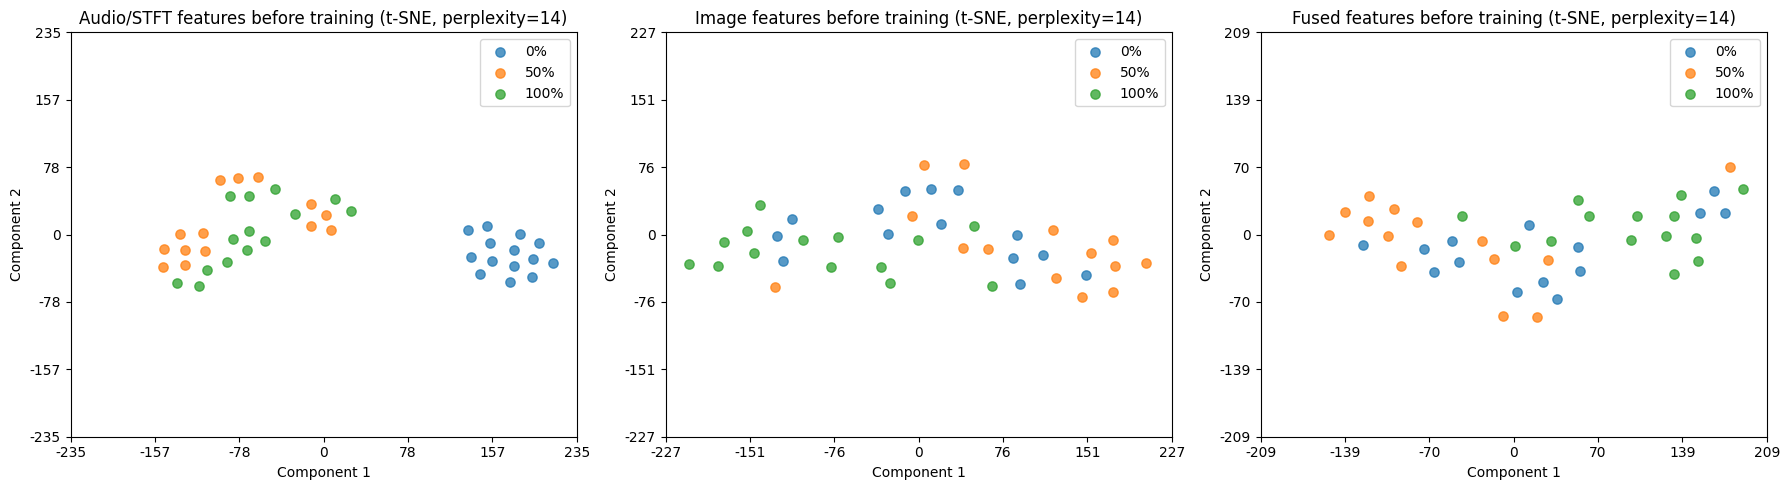

In [284]:
def visualize_features(model, loader, title_suffix: str = "") -> None:
    """Plot audio, image, and fused feature projections with equalized axes and full tick values."""

    audio_features, image_features, fused_features, labels_all, _ = extract_feature_arrays(
        model,
        loader
    )

    feature_sets = [audio_features, image_features, fused_features]
    names = ["Audio/STFT", "Image", "Fused"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for features, name, ax in zip(feature_sets, names, axes):
        projected, method = project_features(features)

        # --------------------------------------------------
        # Equalize axes around zero
        # --------------------------------------------------

        abs_max = max(
            np.max(np.abs(projected[:, 0])),
            np.max(np.abs(projected[:, 1]))
        )

        abs_max *= 1.10  # add 10% padding

        if abs_max == 0:
            abs_max = 1.0

        # Round up for cleaner axis boundaries
        abs_max = np.ceil(abs_max)

        ax.set_xlim(-abs_max, abs_max)
        ax.set_ylim(-abs_max, abs_max)

        # --------------------------------------------------
        # Show intermediary values including min, zero, max
        # --------------------------------------------------

        tick_values = np.linspace(
            -abs_max,
            abs_max,
            7
        )

        ax.set_xticks(tick_values)
        ax.set_yticks(tick_values)

        ax.set_xticklabels(
            [f"{tick:.0f}" for tick in tick_values]
        )

        ax.set_yticklabels(
            [f"{tick:.0f}" for tick in tick_values]
        )

        # --------------------------------------------------
        # Scatter by class
        # --------------------------------------------------

        for class_index, class_name in INDEX_TO_LABEL.items():
            mask = labels_all == class_index

            if mask.any():
                ax.scatter(
                    projected[mask, 0],
                    projected[mask, 1],
                    s=45,
                    alpha=0.75,
                    label=class_name
                )

        ax.set_title(
            f"{name} features {title_suffix} ({method})"
        )

        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.legend()

    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# Visualize features before training
# --------------------------------------------------

visualize_features(
    model=model,
    loader=test_loader,
    title_suffix="before training"
)

## Cell 9: Training and validation loop


In [285]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Run one pass through a loader; pass an optimizer only for training."""

    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, spectrograms, labels in loader:
        images = images.to(DEVICE)
        spectrograms = spectrograms.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(images, spectrograms)
            loss = criterion(logits, labels)

            if is_train:
                # Standard PyTorch update: clear gradients, backprop, then step.
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_count += labels.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


# Cross-entropy expects integer class indices: 0, 1, 2.
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.3f} | "
        f"test loss {test_loss:.4f}, acc {test_acc:.3f}"
    )

/tmp/ipykernel_420/4129557658.py:63: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_pil = Image.fromarray(spectrum_uint8, mode="RGB")


Epoch 01/30 | train loss 0.7811, acc 0.666 | val loss 1.3702, acc 0.337 | test loss 1.4155, acc 0.333
Epoch 02/30 | train loss 0.6420, acc 0.731 | val loss 0.6409, acc 0.783 | test loss 0.6706, acc 0.714
Epoch 03/30 | train loss 0.4671, acc 0.814 | val loss 0.8146, acc 0.566 | test loss 0.9962, acc 0.548
Epoch 04/30 | train loss 0.2705, acc 0.928 | val loss 0.2651, acc 0.916 | test loss 0.3113, acc 0.857
Epoch 05/30 | train loss 0.2084, acc 0.934 | val loss 0.1293, acc 0.940 | test loss 0.2296, acc 0.929
Epoch 06/30 | train loss 0.2000, acc 0.952 | val loss 0.1999, acc 0.916 | test loss 0.2829, acc 0.905
Epoch 07/30 | train loss 0.1285, acc 0.952 | val loss 0.0427, acc 1.000 | test loss 0.1832, acc 0.905
Epoch 08/30 | train loss 0.1367, acc 0.962 | val loss 0.0684, acc 0.964 | test loss 0.2194, acc 0.905
Epoch 09/30 | train loss 0.1894, acc 0.921 | val loss 0.0706, acc 0.964 | test loss 0.1740, acc 0.905
Epoch 10/30 | train loss 0.1432, acc 0.945 | val loss 0.0660, acc 0.988 | test los

## Cell 10: Plot training curves


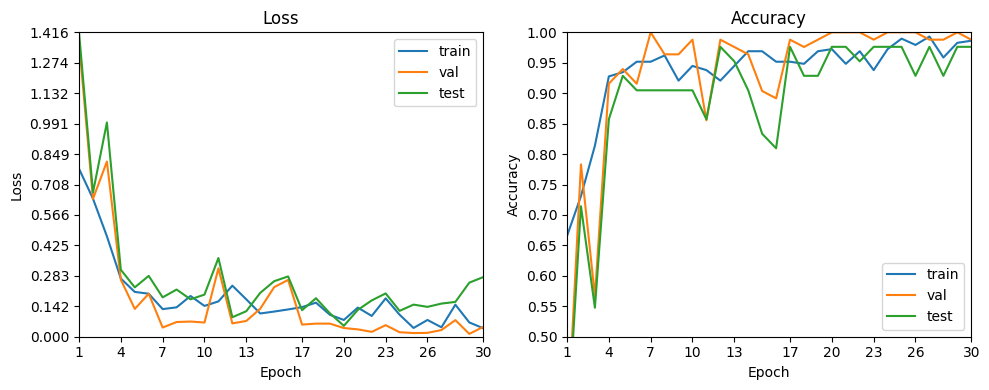

In [286]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Use real epoch numbers: 1, 2, 3, ..., max_epoch
max_epoch = len(history["train_loss"])
epochs = np.arange(1, max_epoch + 1)

# X-axis ticks, always including the maximum epoch
x_ticks = np.linspace(1, max_epoch, min(10, max_epoch)).astype(int)
x_ticks = np.unique(np.append(x_ticks, max_epoch))

# ---------------- Loss ----------------
train_loss = np.array(history["train_loss"])
val_loss = np.array(history["val_loss"])
test_loss = np.array(history["test_loss"])

loss_values = np.concatenate([train_loss, val_loss, test_loss])
loss_min = 0.0
loss_max = loss_values.max()

axs[0].plot(epochs, train_loss, label="train")
axs[0].plot(epochs, val_loss, label="val")
axs[0].plot(epochs, test_loss, label="test")

axs[0].set_xlim(1, max_epoch)
axs[0].set_xticks(x_ticks)
axs[0].set_ylim(loss_min, loss_max)
axs[0].margins(x=0, y=0)

# Y-ticks at 10% intervals
loss_ticks = np.linspace(0, loss_max, 11)
axs[0].set_yticks(loss_ticks)
axs[0].set_yticklabels([f"{tick:.3f}" for tick in loss_ticks])

axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss")
axs[0].legend()

# ---------------- Accuracy ----------------
train_acc = np.array(history["train_acc"])
val_acc = np.array(history["val_acc"])
test_acc = np.array(history["test_acc"])

acc_values = np.concatenate([train_acc, val_acc, test_acc])
acc_min = 0.5
acc_max = acc_values.max()

axs[1].plot(epochs, train_acc, label="train")
axs[1].plot(epochs, val_acc, label="val")
axs[1].plot(epochs, test_acc, label="test")

axs[1].set_xlim(1, max_epoch)
axs[1].set_xticks(x_ticks)
axs[1].set_ylim(acc_min, acc_max)
axs[1].margins(x=0, y=0)

# Y-ticks from 50% to max using equal intervals
acc_ticks = np.linspace(acc_min, acc_max, 11)
axs[1].set_yticks(acc_ticks)
axs[1].set_yticklabels([f"{tick:.2f}" for tick in acc_ticks])

axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].set_title("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()

## Cell 11: Validation/test predictions, reports, and test confusion matrix


/tmp/ipykernel_420/4129557658.py:63: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_pil = Image.fromarray(spectrum_uint8, mode="RGB")


Validation classification report
              precision    recall  f1-score   support

          0%       0.97      1.00      0.98        28
         50%       1.00      1.00      1.00        28
        100%       1.00      0.96      0.98        27

    accuracy                           0.99        83
   macro avg       0.99      0.99      0.99        83
weighted avg       0.99      0.99      0.99        83

Test classification report
              precision    recall  f1-score   support

          0%       1.00      1.00      1.00        14
         50%       0.93      1.00      0.97        14
        100%       1.00      0.93      0.96        14

    accuracy                           0.98        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



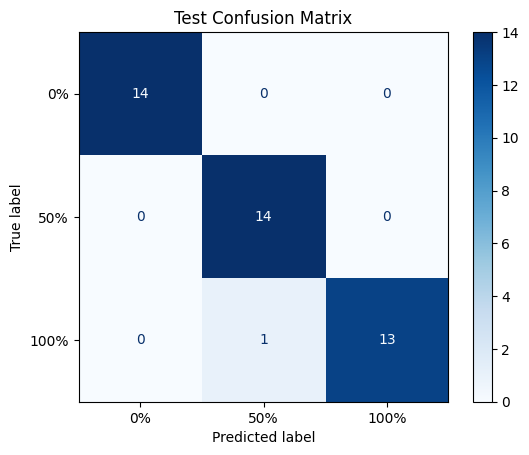

In [287]:
def collect_predictions(model, loader):
    """Collect class predictions from a loader without updating weights."""

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, spectrograms, labels in loader:
            logits = model(images.to(DEVICE), spectrograms.to(DEVICE))
            y_true.extend(labels.numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    return np.array(y_true), np.array(y_pred)


val_true, val_pred = collect_predictions(model, val_loader)
test_true, test_pred = collect_predictions(model, test_loader)
y_true, y_pred = test_true, test_pred
target_names = [INDEX_TO_LABEL[i] for i in range(len(INDEX_TO_LABEL))]
print("Validation classification report")
print(classification_report(val_true, val_pred, target_names=target_names, zero_division=0))
print("Test classification report")
print(classification_report(test_true, test_pred, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(target_names))))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(cmap="Blues")
plt.title("Test Confusion Matrix")
plt.show()

## Cell 12: Test per-class accuracy and feature projection after training


## (a) Bar Chart

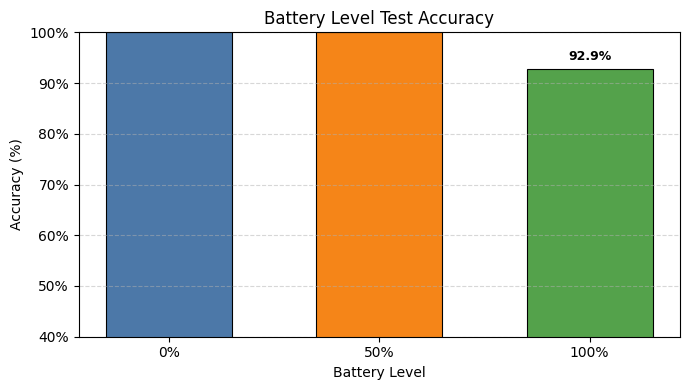

In [288]:
def plot_class_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """Plot battery-level accuracy from 40% to 100%, showing bar-top labels if accuracy < 100%."""
    accuracies = []
    class_names = ["0%", "50%", "100%"]

    for class_index in range(len(class_names)):
        mask = y_true == class_index
        if mask.any():
            accuracy = float((y_pred[mask] == class_index).mean())
            accuracies.append(accuracy)
        else:
            accuracies.append(np.nan)

    x = np.arange(len(class_names))
    heights = np.array(accuracies, dtype=float) * 100
    fig, ax = plt.subplots(figsize=(7, 4))
    bar_colors = ["#4C78A8", "#F58518", "#54A24B"]
    plot_heights = np.nan_to_num(heights, nan=0.0)

    bars = ax.bar(x, plot_heights, color=bar_colors, edgecolor="black", linewidth=0.8, width=0.6)

    for i, accuracy in enumerate(heights):
        if np.isnan(accuracy):
            bars[i].set_facecolor("#CCCCCC")
            bars[i].set_edgecolor("#666666")
        elif accuracy < 100:
            ax.text(
                x[i], accuracy + 1, f"{accuracy:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_xlabel("Battery Level")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(40, 100)
    ax.set_yticks([40, 50, 60, 70, 80, 90, 100])
    ax.set_yticklabels(["40%", "50%", "60%", "70%", "80%", "90%", "100%"])
    ax.set_title("Battery Level Test Accuracy")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
plot_class_accuracy(y_true, y_pred)

## (b) Per class accuracy

/tmp/ipykernel_420/4129557658.py:63: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_pil = Image.fromarray(spectrum_uint8, mode="RGB")


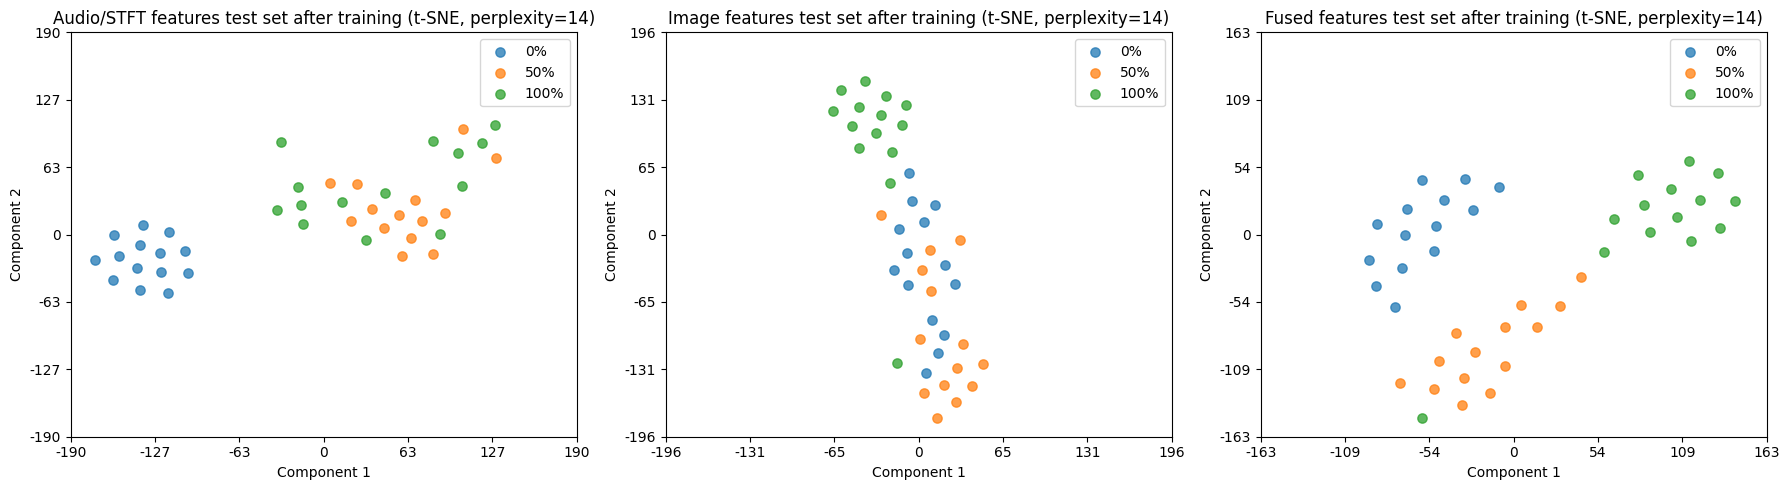

In [289]:
def visualize_correctness_projection(model, loader) -> None:
    """Project fused test features and color points by correct vs wrong prediction with equal axes and ticks."""

    _, _, fused_features, labels_all, preds_all = extract_feature_arrays(model, loader)
    projected, method = project_features(fused_features)
    correct = labels_all == preds_all

    x_values = projected[:, 0]
    y_values = projected[:, 1]

    # --------------------------------------------------
    # Symmetric axes around zero
    # --------------------------------------------------
    abs_max = max(np.max(np.abs(x_values)), np.max(np.abs(y_values)))
    abs_max *= 1.10  # 10% padding
    if abs_max == 0:
        abs_max = 1.0
    abs_max = np.ceil(abs_max)

    fig, ax = plt.subplots(figsize=(7, 5))

    # --------------------------------------------------
    # Scatter points
    # --------------------------------------------------
    if correct.any():
        ax.scatter(projected[correct, 0], projected[correct, 1], s=55, color="green", alpha=0.7, label="Correct")
    if (~correct).any():
        ax.scatter(projected[~correct, 0], projected[~correct, 1], s=55, color="red", alpha=0.7, label="Wrong")

    # --------------------------------------------------
    # Set symmetric limits
    # --------------------------------------------------
    ax.set_xlim(-abs_max, abs_max)
    ax.set_ylim(-abs_max, abs_max)

    # --------------------------------------------------
    # Automatic intermediary ticks + show extremes as +max/-max
    # --------------------------------------------------
    tick_count = 7  # number of ticks including min/max
    ticks = np.linspace(-abs_max, abs_max, tick_count)

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_xticklabels([f"{tick:.0f}" for tick in ticks])
    ax.set_yticklabels([f"{tick:.0f}" for tick in ticks])

    ax.set_title(f"Test Correctness Projection ({method})")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend()

    plt.tight_layout()
    plt.show()

visualize_features(model, test_loader, title_suffix="test set after training")

## Cell 13: Test correctness projection


/tmp/ipykernel_420/4129557658.py:63: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_pil = Image.fromarray(spectrum_uint8, mode="RGB")


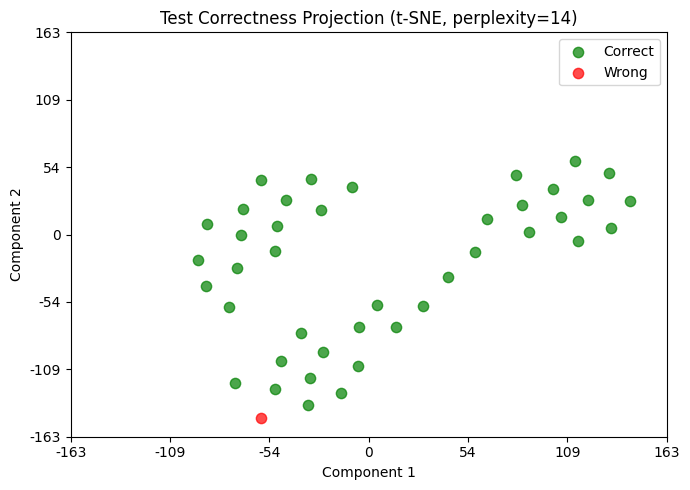

In [290]:
def visualize_correctness_projection(model, loader) -> None:
    """Project fused test features and color points by correct vs wrong prediction."""

    _, _, fused_features, labels_all, preds_all = extract_feature_arrays(
        model,
        loader
    )

    projected, method = project_features(fused_features)
    correct = labels_all == preds_all

    # --------------------------------------------------
    # Equalize axes around zero
    # --------------------------------------------------

    x_values = projected[:, 0]
    y_values = projected[:, 1]

    abs_max = max(
        np.max(np.abs(x_values)),
        np.max(np.abs(y_values))
    )

    abs_max *= 1.10  # add 10% padding

    if abs_max == 0:
        abs_max = 1.0

    abs_max = np.ceil(abs_max)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, ax = plt.subplots(figsize=(7, 5))

    if correct.any():
        ax.scatter(
            projected[correct, 0],
            projected[correct, 1],
            s=55,
            color="green",
            alpha=0.7,
            label="Correct"
        )

    if (~correct).any():
        ax.scatter(
            projected[~correct, 0],
            projected[~correct, 1],
            s=55,
            color="red",
            alpha=0.7,
            label="Wrong"
        )

    # --------------------------------------------------
    # Symmetric limits
    # --------------------------------------------------

    ax.set_xlim(-abs_max, abs_max)
    ax.set_ylim(-abs_max, abs_max)

    # --------------------------------------------------
    # Show intermediary values including min, zero, max
    # --------------------------------------------------

    tick_values = np.linspace(
        -abs_max,
        abs_max,
        7
    )

    ax.set_xticks(tick_values)
    ax.set_yticks(tick_values)

    ax.set_xticklabels(
        [f"{tick:.0f}" for tick in tick_values]
    )

    ax.set_yticklabels(
        [f"{tick:.0f}" for tick in tick_values]
    )

    ax.set_title(f"Test Correctness Projection ({method})")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend()

    plt.tight_layout()
    plt.show()

visualize_correctness_projection(model, test_loader)

## Cell 14: Save trained model and label mapping


In [291]:
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_to_index": LABEL_TO_INDEX,
        "index_to_label": INDEX_TO_LABEL,
    },
    MODEL_OUT,
)
MODEL_OUT

PosixPath('/content/drive/MyDrive/Colab Notebooks/Research/CoBas/Machine Learning/Models/multimodal_fusion_model.pth')